# Introducción

## Importar librerías

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Valores nominales

In [2]:
# Datos del POI
VnPOI = 115 #kV

# Datos del inversor
Sn = 120 # MW
Vterm = 0.6 #kV
IBaseIBR = Sn/(np.sqrt(3)*Vterm) # kA

## Definición de funciones

In [3]:
# Función para calcular las columnas adicionales en el DataFrame de PSS/E
def read_csv_pss_file(directory):
    if directory is None or not os.path.isfile(directory):
        print(f"Error: El archivo '{directory}' no existe o la ruta es inválida.")
        return 'Error'
    else:
        pssframe = pd.read_csv(directory, skiprows=1)
        # Obtener el voltaje de cuadratura desde PSS/E
        Vt_angle = pssframe[' IBRT_ANGLE']
        pssframe['IBR_V (kV)'] = pssframe[' IBRT_V']*Vterm
        pssframe['IBR_VINT (kV)'] = pssframe[' IBR_VT']*Vterm
        pssframe['PLL_DELTA (Degree)'] = pssframe[' IBR_DELTA_PLL']*180/np.pi
        pssframe['VQ_PLL (kV)'] = pssframe['IBR_V (kV)']*np.sin((Vt_angle-pssframe['PLL_DELTA (Degree)'])*np.pi/180)

        pssframe['IBR_P (MW)']  = pssframe[' IBR_P']*100
        pssframe['IBR_ID (kA)'] = pssframe['IBR_P (MW)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']

        pssframe['IBR_Q (MVAR)'] = pssframe[' IBR_Q']*100
        pssframe['IBR_IQ (kA)']  = pssframe['IBR_Q (MVAR)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']

        pssframe['IBR_S (MVA)'] = np.sqrt(pssframe['IBR_P (MW)']**2 + pssframe['IBR_Q (MVAR)']**2)
        pssframe['IBR_pf (pu)'] = pssframe['IBR_P (MW)']/pssframe['IBR_S (MVA)']

        pssframe['POI_S (MVA)'] = np.sqrt(pssframe[' POI_P']**2 + pssframe[' POI_Q']**2)
        pssframe['POI_pf (pu)'] = pssframe['IBR_P (MW)']/pssframe['POI_S (MVA)']
        return pssframe

In [4]:
# Función para procesar los encabezados del archivo de resultados de DIgSILENT
def read_csv_dsl_file(directory):
    dslframe = pd.read_csv(directory, header=None, low_memory=False)
    if dslframe is None or dslframe.empty:
        print(f"Error: El archivo '{directory}' no se pudo leer o está vacío.")
        return None
    else:
        tmprow = dslframe.iloc[0].astype(str) + ' ' + dslframe.iloc[1].astype(str)
        tmp_df = dslframe.drop([0,1], axis=0)
        dslframe = pd.concat([tmprow.to_frame().T, tmp_df], ignore_index=True)
        dslframe.iloc[0,0] = 'Time in S'
        dslframe.columns = dslframe.iloc[0]
        dslframe.drop([0], axis=0, inplace=True)
        dslframe = dslframe.apply(pd.to_numeric)
        return dslframe

## DIgSILENT

Toda esta sección se puede desactivar si no se cuenta con DIgSILENT o si ya se cuenta con los archivos de resultados

In [5]:
os.environ["PATH"] = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP1" + os.environ["PATH"]  # Importamos estas librerías y archivos para enlazar nuestro intérprete de python (En mi caso, Spyder) con DIgSILENT
sys.path.append("C:\\Program Files\\DIgSILENT\\PowerFactory 2025 SP1\\Python\\3.11")
import powerfactory
app = powerfactory.GetApplicationExt() # Importamos las librerías de DIgSILENT y otras librerías que se usan en el código
app.Show()                             # mostramos DIgSILENT en pantalla para ver qué está haciendo
user = app.GetCurrentUser()            # Obtenemos el usuario activo
dsl_folder_main = r"C:\Users\diego.montesanos\OneDrive - Funken Ingenieros S.A. de C.V\Documentos\FKTrabajo\2026 22 Dinámica PSSE Vs DIgSILENT\REEC_E"

Activar proyecto

In [6]:
oProject = user.GetContents('DYN DIgSILENT x PSSE.IntPrj')[0]  # Seleccionamos el primer proyecto dentro del folder
oProject.Activate()                                            # Activamos el proyecto

0

In [85]:
# Main switch para variación del modelo
REEC_E_modes = [
#    'REGC_C',
    # 'REEC_E Modo 01',
    # 'REEC_E Modo 02',
    'REEC_E Modo 03',
    # 'REEC_E Modo 04',
    # 'REEC_E Modo 05',
    # 'REEC_E Modo 06',
    # 'REEC_E Modo 07',
    # 'REEC_E Modo 08',
    # 'REEC_E Modo 09',
    # 'REEC_E Modo 10',
    # 'REEC_E Modo 11',
    # 'REEC_E Modo 12',
    # 'REEC_E Modo 13',
    # 'REEC_E Modo 14'
]


In [86]:
oFoldVarts = app.GetProjectFolder('scheme')     # Seleccionamos el folder de variaciones
oFoldREECE = oFoldVarts.GetContents('REEC_E')[0]

app.EchoOff()  # Congelamos la interfaz del usuario
app.ClearOutputWindow()  # Borramos el "Output window"

dsl_names = {
    0 : 'dsl_plano.csv',
    1 : 'dsl_falla_parcial.csv',
    2 : 'dsl_falla_total.csv',
    3 : 'dsl_per_fase.csv',
    4 : 'dsl_per_freq.csv',
    5 : 'dsl_per_volt.csv',
    6 : 'dsl_esc_Paux.csv',
    7 : 'dsl_esc_Pref.csv',
    8 : 'dsl_esc_Qref.csv',
    9 : 'dsl_esc_PFref.csv'
}

for REEC_E_mode in REEC_E_modes:
    app.PrintPlain(f"Procesando el folder: {REEC_E_mode}...")
    dsl_folder = dsl_folder_main + "\\" + REEC_E_mode
    oFoldStudy = app.GetProjectFolder('study')
    oFoldStudy = oFoldStudy.GetContents(REEC_E_mode)[0]  # Seleccionar el folder de estudio indicado en "folder"
    oSelectVar = oFoldREECE.GetContents(REEC_E_mode)[0]  # Obtenemos la variacion que queremos activar para cada caso de estudio

    # Todos los casos de estudio en el folder especificado
    sStudyCase = oFoldStudy.GetContents('*.IntCase')
    sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

    for oStudyCase in sStudyCase:
        nCase = int(oStudyCase.loc_name[0:2])
        if nCase in dsl_names.keys():
            app.PrintPlain(f"   Procesando el caso de estudio: {oStudyCase}...")
            oStudyCase.Activate()

            sActiveVar = app.GetActiveNetworkVariations()   # Obtenemos las variaciones activas en el caso de estudio
            [oActiveVar.Deactivate() for oActiveVar in sActiveVar]
            oSelectVar.Activate()
            
            oInit = oStudyCase.GetContents('*.ComInc')[0]
            oRun  = oStudyCase.GetContents('*.ComSim')[0]
            oInit.Execute()
            oRun.Execute()

            oElmRes = app.GetFromStudyCase('ElmRes')
            oElmExp = app.GetFromStudyCase('ComRes')

            oElmExp.iopt_exp = 6
            oElmExp.f_name = dsl_folder + "\\" + dsl_names[nCase]
            oElmExp.pResult = oElmRes
            oElmExp.Execute()

    try: dsl_flt = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[0])
    except: dsl_flt = None; print('Prueba 0 no disponible')
    try: dsl_par = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[1])
    except: dsl_par = None; print('Prueba 1 no disponible')
    try: dsl_tot = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[2])
    except: dsl_tot = None; print('Prueba 2 no disponible')
    try: dsl_phi = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[3])
    except: dsl_phi = None; print('Prueba 3 no disponible')
    try: dsl_frq = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[4])
    except: dsl_frq = None; print('Prueba 4 no disponible')
    try: dsl_vol = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[5])
    except: dsl_vol = None; print('Prueba 5 no disponible')
    try: dsl_pax = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[6])
    except: dsl_pax = None; print('Prueba 6 no disponible')
    try: dsl_prf = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[7])
    except: dsl_prf = None; print('Prueba 7 no disponible')
    try: dsl_qrf = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[8])
    except: dsl_qrf = None; print('Prueba 8 no disponible')
    try: dsl_PFr = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[9])
    except: dsl_PFr = None; print('Prueba 9 no disponible')

app.EchoOn()  # Descongelamos la interfaz del usuario

## PSS/E

In [9]:
# Solo con el REGC_C
if REEC_E_modes[0] == 'REGC_C':
    dir_temp = "\\REGCC - PSSE\\"
elif REEC_E_modes[0] == 'REEC_E Modo 01':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 01\\"
elif REEC_E_modes[0] == 'REEC_E Modo 02':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 02\\"
elif REEC_E_modes[0] == 'REEC_E Modo 03':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 03\\"
elif REEC_E_modes[0] == 'REEC_E Modo 04':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 04\\"
elif REEC_E_modes[0] == 'REEC_E Modo 05':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 05\\"
elif REEC_E_modes[0] == 'REEC_E Modo 06':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 06\\"
elif REEC_E_modes[0] == 'REEC_E Modo 07':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 07\\"
elif REEC_E_modes[0] == 'REEC_E Modo 08':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 08\\"
elif REEC_E_modes[0] == 'REEC_E Modo 09':    
    dir_temp = "\\REGCC + REECE - PSSE\MODO 09\\"
elif REEC_E_modes[0] == 'REEC_E Modo 10':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 10\\"
elif REEC_E_modes[0] == 'REEC_E Modo 11':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 11\\"
elif REEC_E_modes[0] == 'REEC_E Modo 12':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 12\\"
elif REEC_E_modes[0] == 'REEC_E Modo 13':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 13\\"
elif REEC_E_modes[0] == 'REEC_E Modo 14':
    dir_temp = "\\REGCC + REECE - PSSE\MODO 14\\"

pss_flt_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"ARRANQUE_PLANO\ibr_plano.csv"
pss_par_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"FALLAS\FALLA_PARCIAL\ibr_falla_parcial.csv"
pss_tot_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"FALLAS\FALLA_TOTAL\ibr_falla_total.csv"
pss_phi_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"PERTURBACIONES\PERT_FASE\ibr_pert_fase.csv"
pss_frq_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"PERTURBACIONES\PERT_FRECUENCIA - PASO\ibr_pert_frq.csv"
pss_vol_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"PERTURBACIONES\PERT_VOLTAJE\ibr_pert_voltaje.csv"
pss_pax_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"ESCALONES\ESC_PAUX\ibr_escalones_paux.csv"
pss_prf_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"ESCALONES\ESC_PREF\ibr_escalones_pref.csv"
pss_qrf_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"ESCALONES\ESC_QREF\ibr_escalones_qref.csv"
pss_PFr_path = r"X:\2026 Modelos IBR PSSE - DIgSILENT" + dir_temp + r"ESCALONES\ESC_PFREF\ibr_escalones_pfref.csv"

In [10]:
pss_flt = read_csv_pss_file(pss_flt_path)
pss_par = read_csv_pss_file(pss_par_path)
pss_tot = read_csv_pss_file(pss_tot_path)
pss_phi = read_csv_pss_file(pss_phi_path)
pss_frq = read_csv_pss_file(pss_frq_path)
pss_vol = read_csv_pss_file(pss_vol_path)
pss_pax = read_csv_pss_file(pss_pax_path)
pss_prf = read_csv_pss_file(pss_prf_path)
pss_qrf = read_csv_pss_file(pss_qrf_path)
pss_PFr = read_csv_pss_file(pss_PFr_path)

Error: El archivo 'X:\2026 Modelos IBR PSSE - DIgSILENT\REGCC + REECE - PSSE\MODO 03\ESCALONES\ESC_PFREF\ibr_escalones_pfref.csv' no existe o la ruta es inválida.


# Pruebas con REGC_C

## 0 - Inicio Plano

### POI

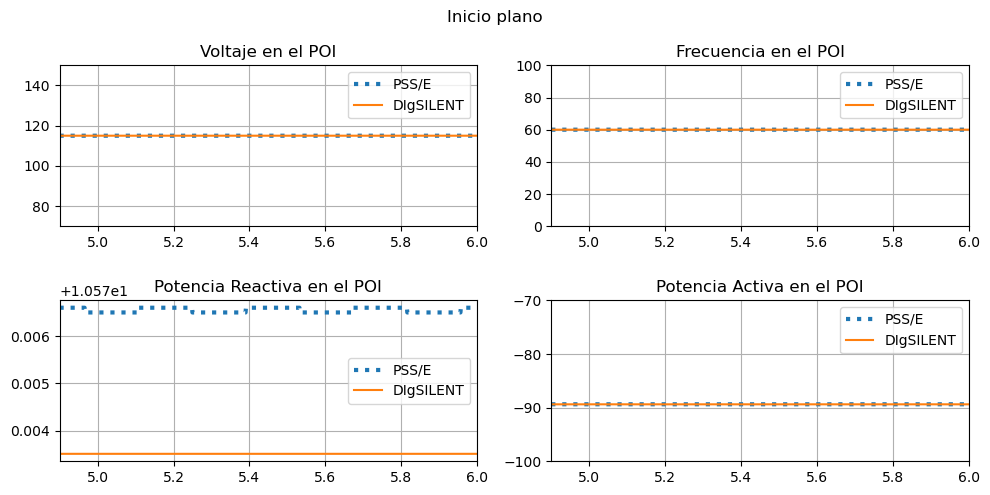

In [87]:
pss_data = pss_flt
dsl_data = dsl_flt
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(10,5))
    fig.suptitle('Inicio plano')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

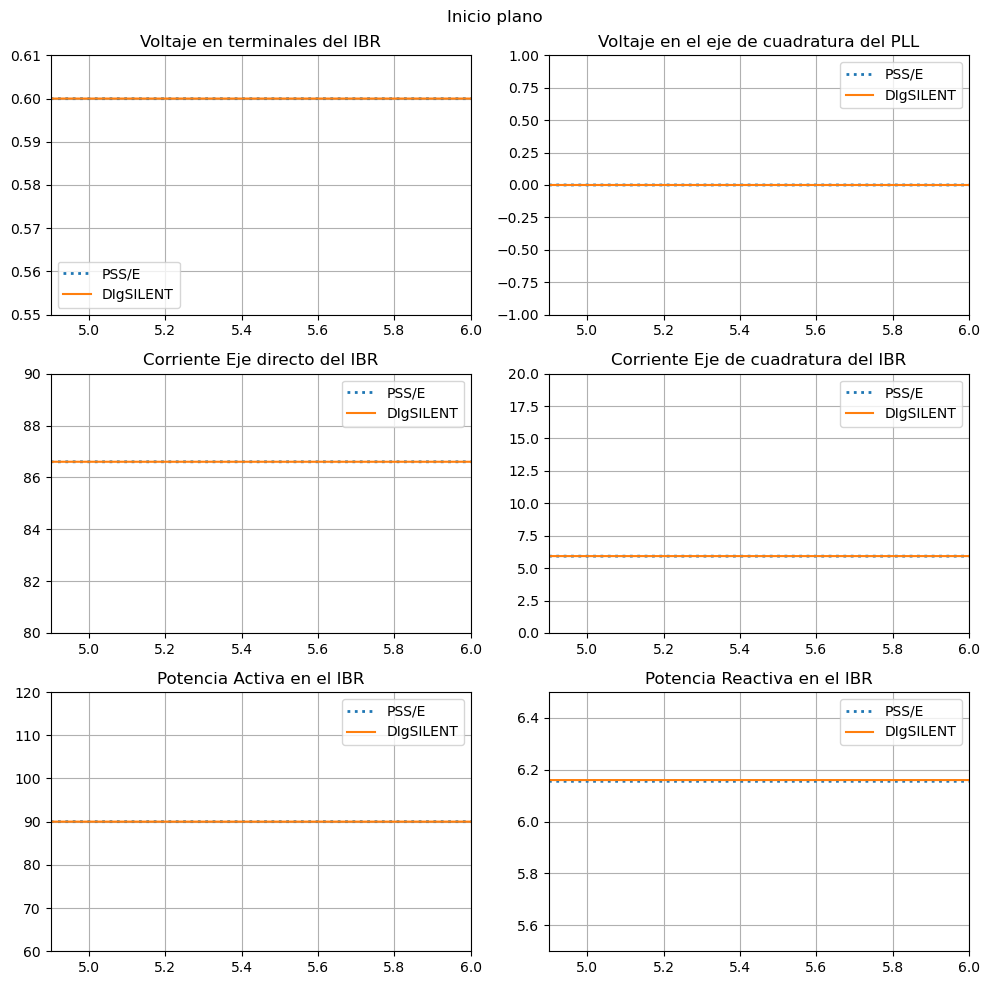

In [88]:
pss_data = pss_flt
dsl_data = dsl_flt
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Inicio plano')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT') #!!!! Calcular a parte
    axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 1 - Falla Parcial

### POI

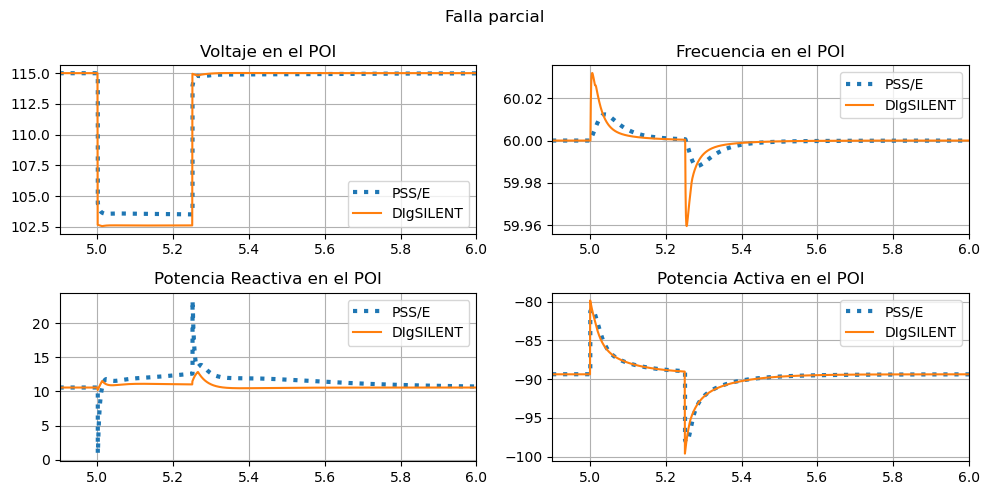

In [62]:
pss_data = pss_par
dsl_data = dsl_par
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(10,5))
    fig.suptitle('Falla parcial')


    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

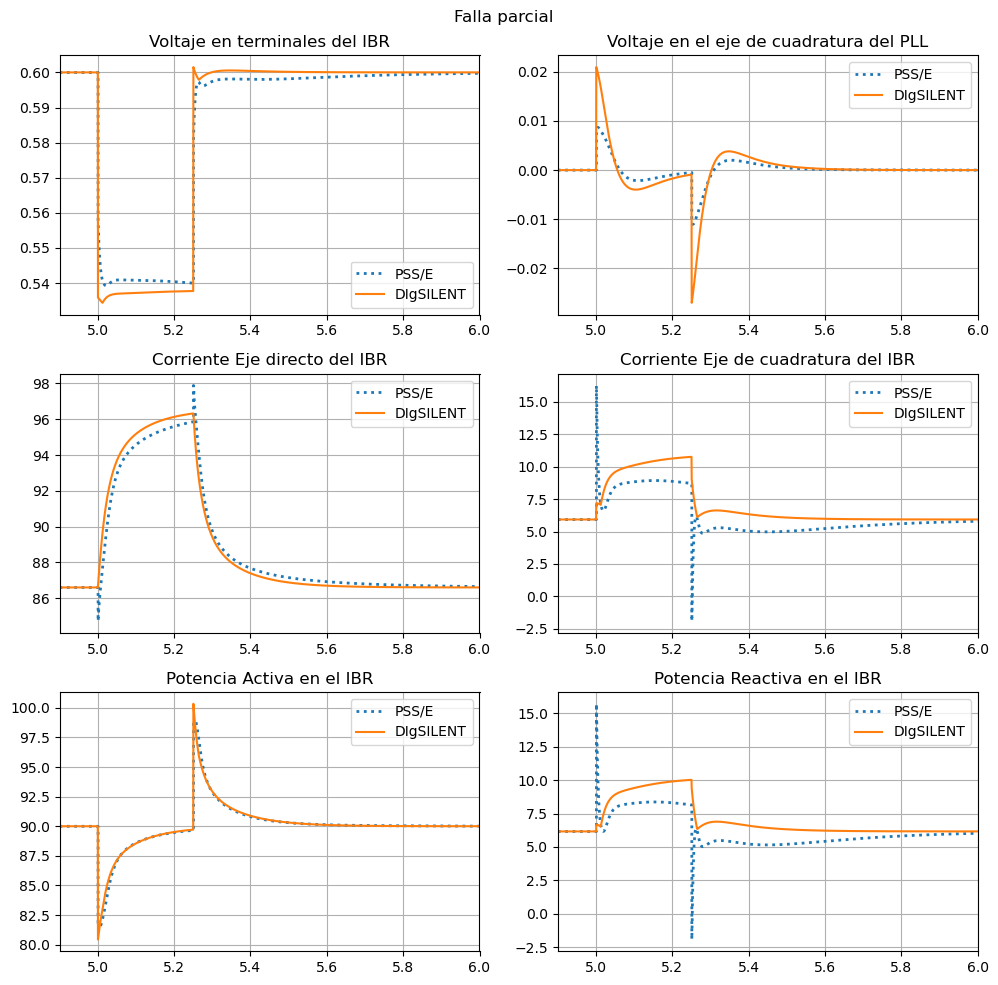

In [63]:
pss_data = pss_par
dsl_data = dsl_par
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla parcial')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT') #!!!! Calcular a parte
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 2 - Falla total

### POI

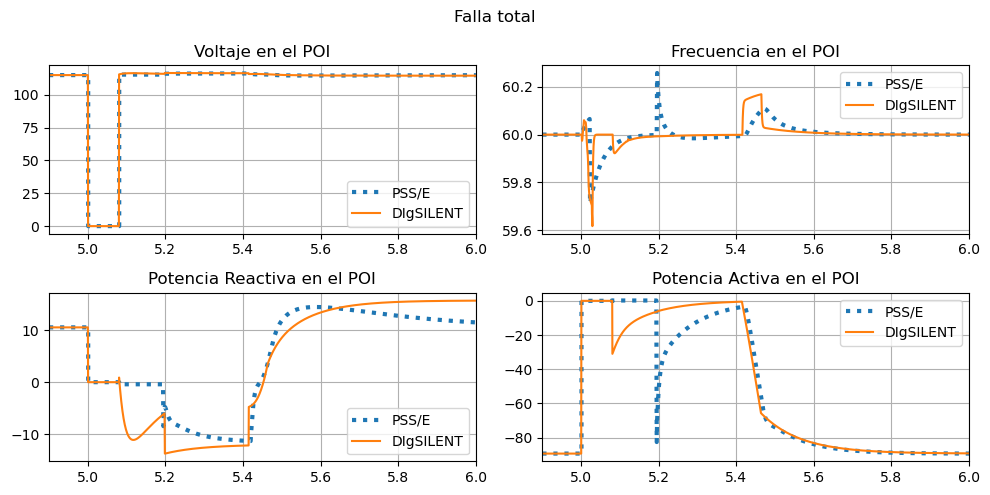

In [64]:
pss_data = pss_tot
dsl_data = dsl_tot
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(2, 2, figsize=(10,5))
    fig.suptitle('Falla total')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

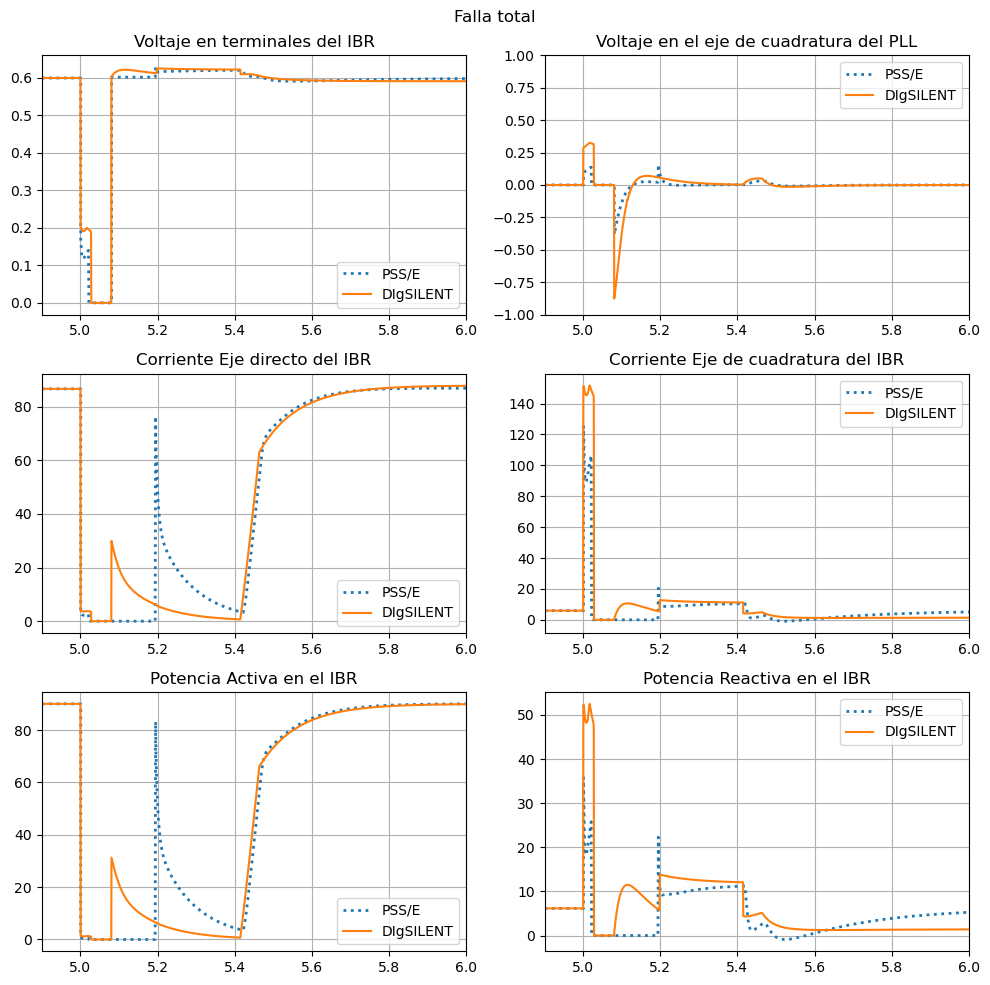

In [65]:
pss_data = pss_tot
dsl_data = dsl_tot
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla total')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 3 - Perturbación de fase

### POI

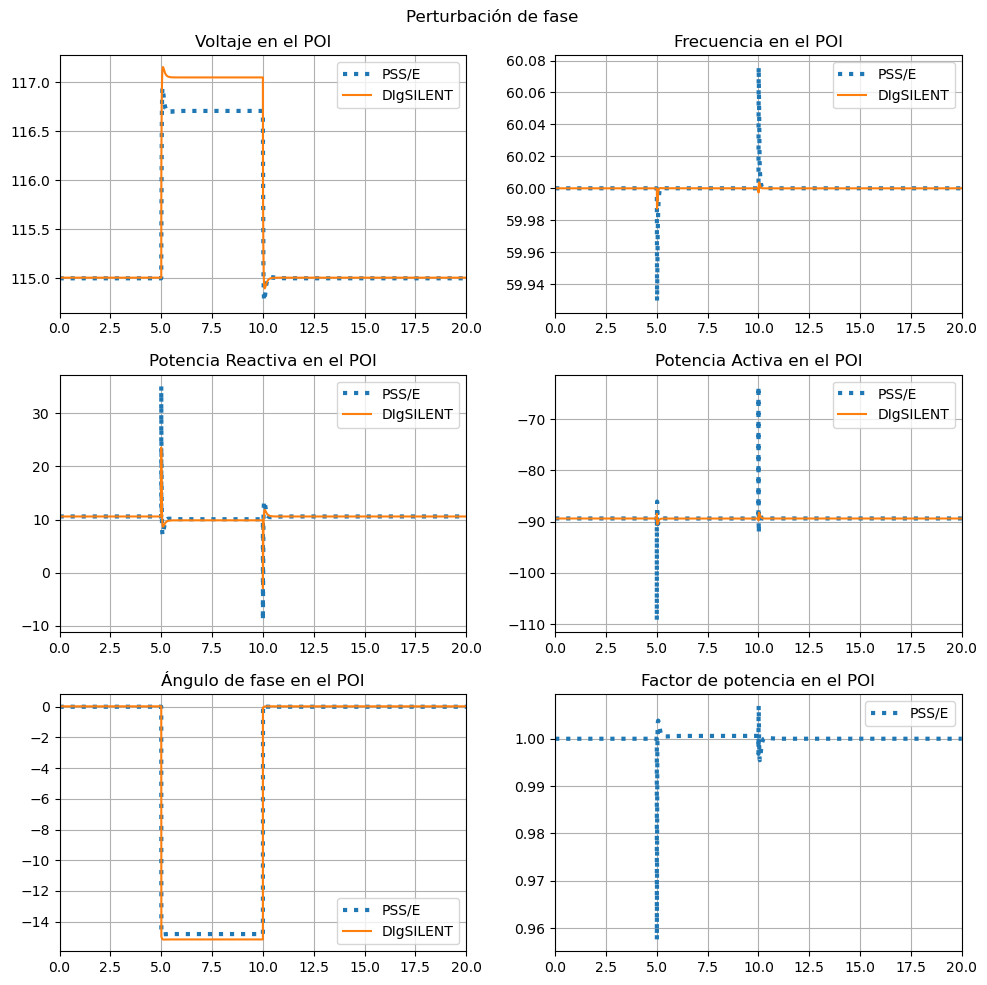

In [66]:
pss_data = pss_phi
dsl_data = dsl_phi
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de fase')

# Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()


    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

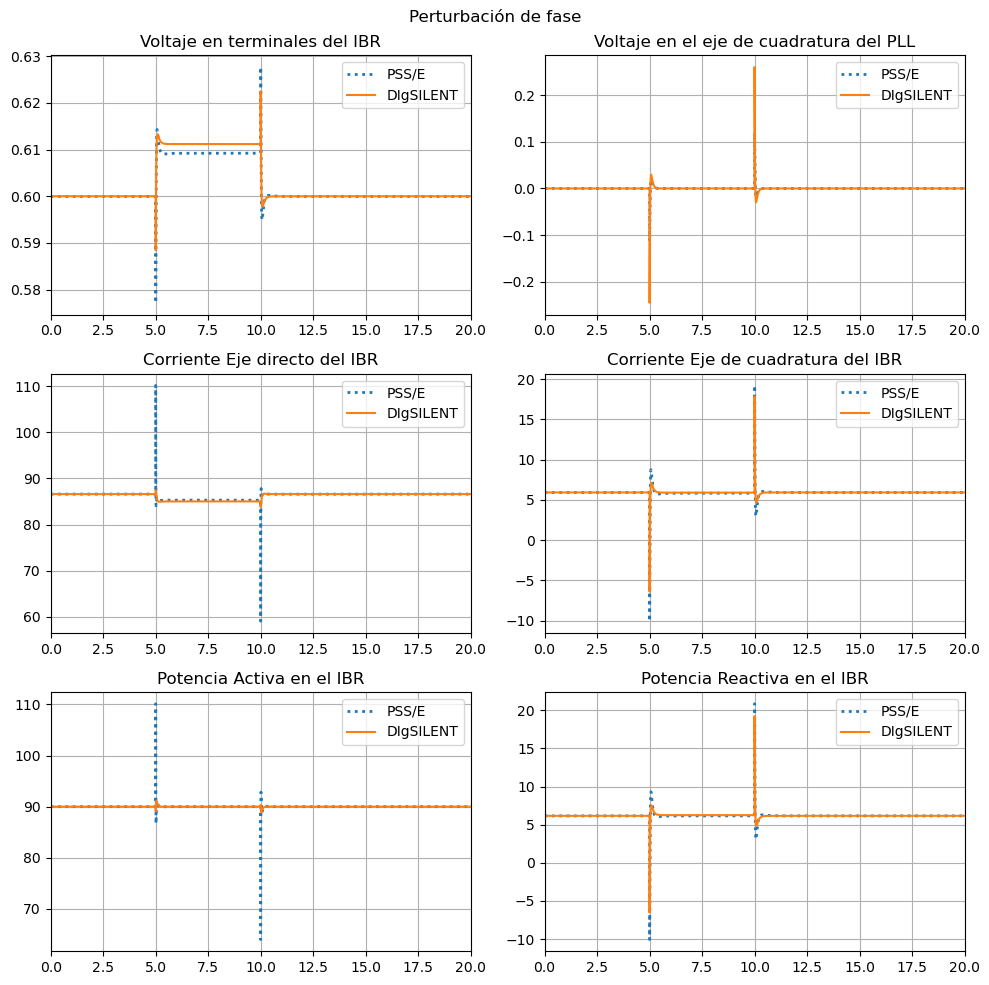

In [67]:
pss_data = pss_phi
dsl_data = dsl_phi
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:      
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de fase')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 4 - Perturbación de frecuencia

### POI

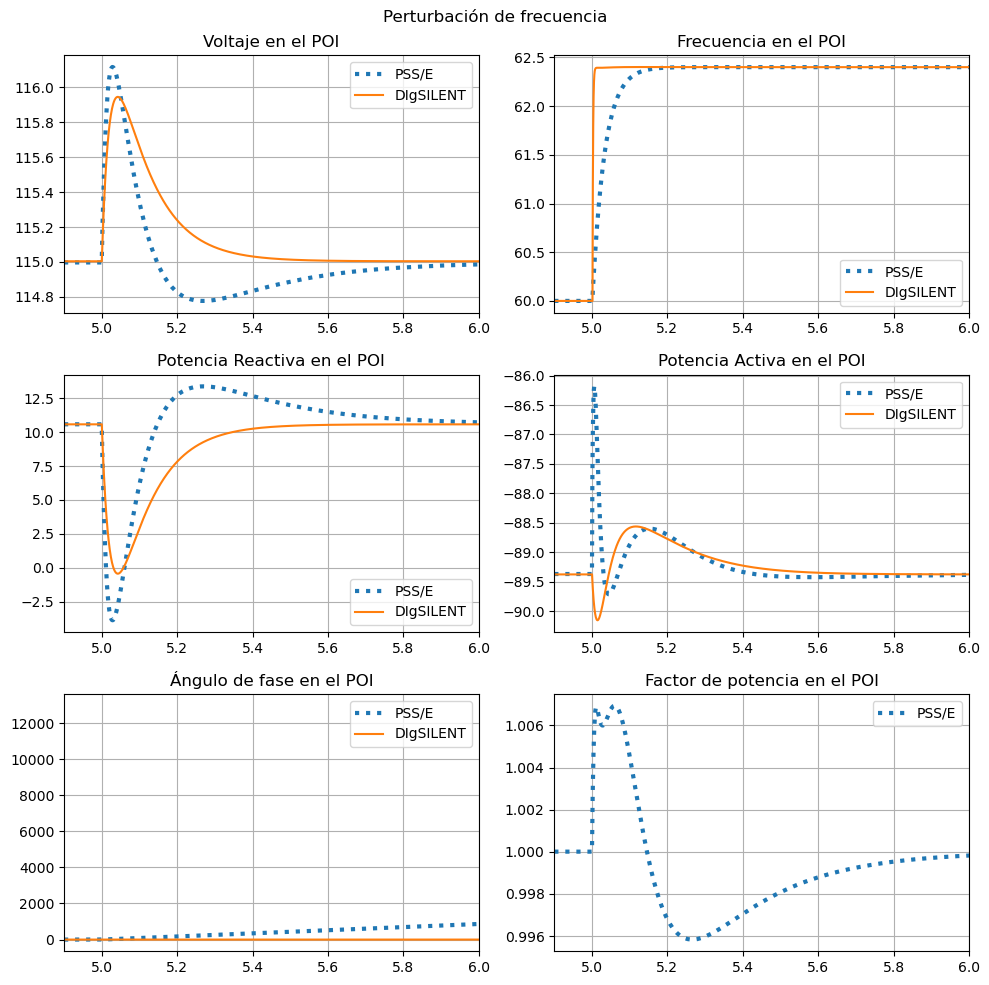

In [68]:
pss_data = pss_frq
dsl_data = dsl_frq
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de frecuencia')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()


    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

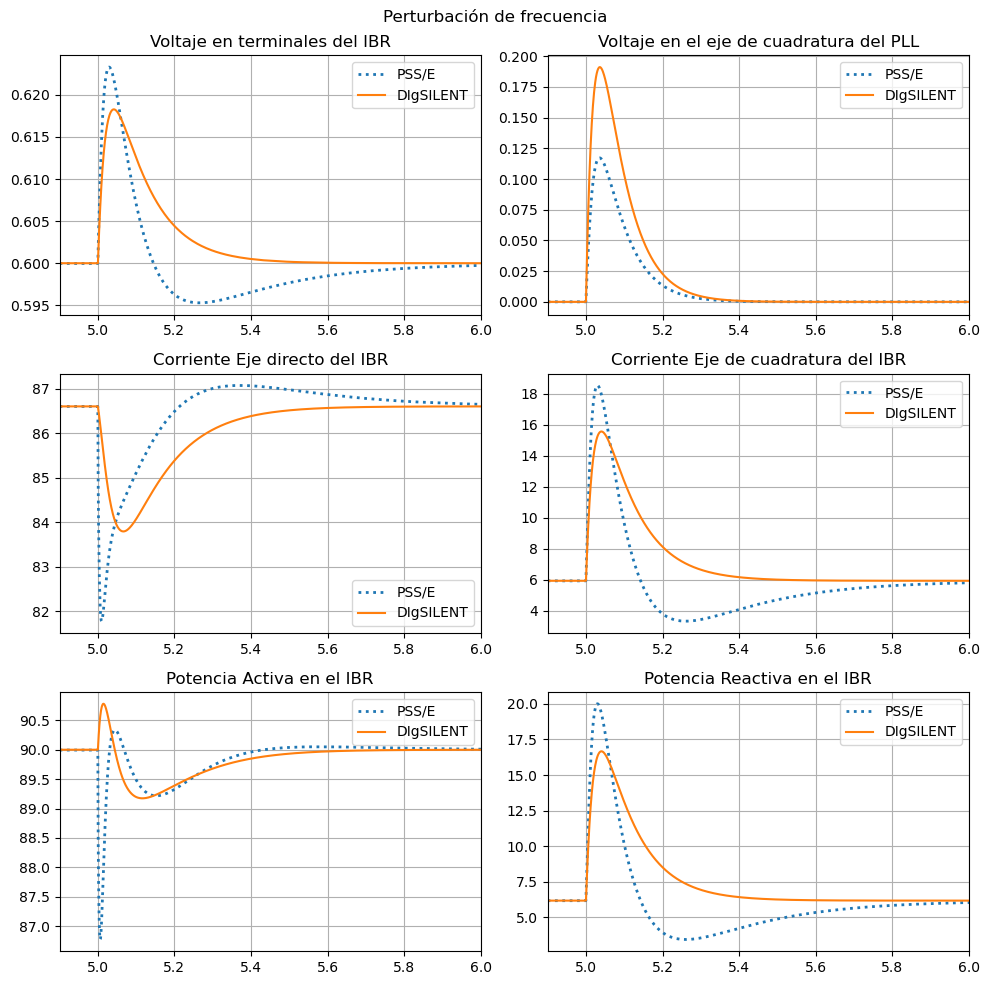

In [69]:
pss_data = pss_frq
dsl_data = dsl_frq
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de frecuencia')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 5 - Perturbación de voltaje

### POI

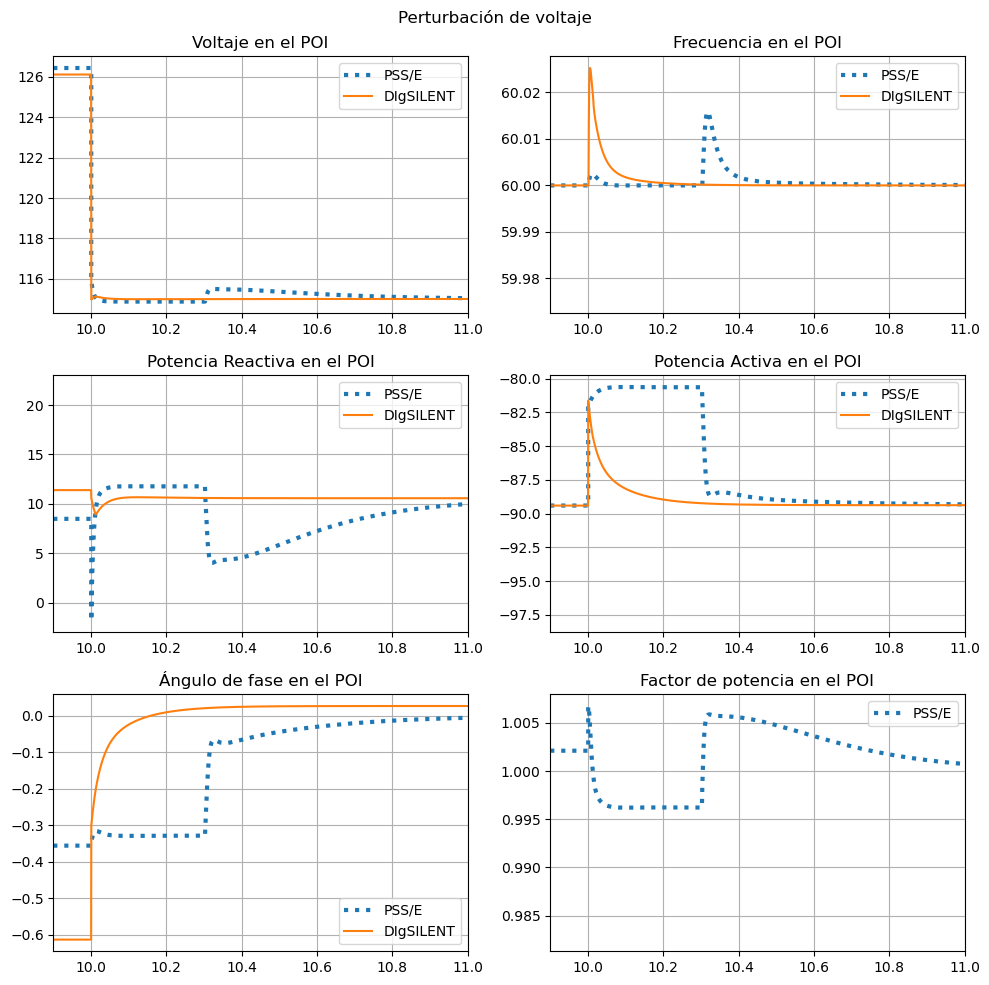

In [70]:
pss_data = pss_vol
dsl_data = dsl_vol
minx = 9.9
maxx = 11

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de voltaje')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()


    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

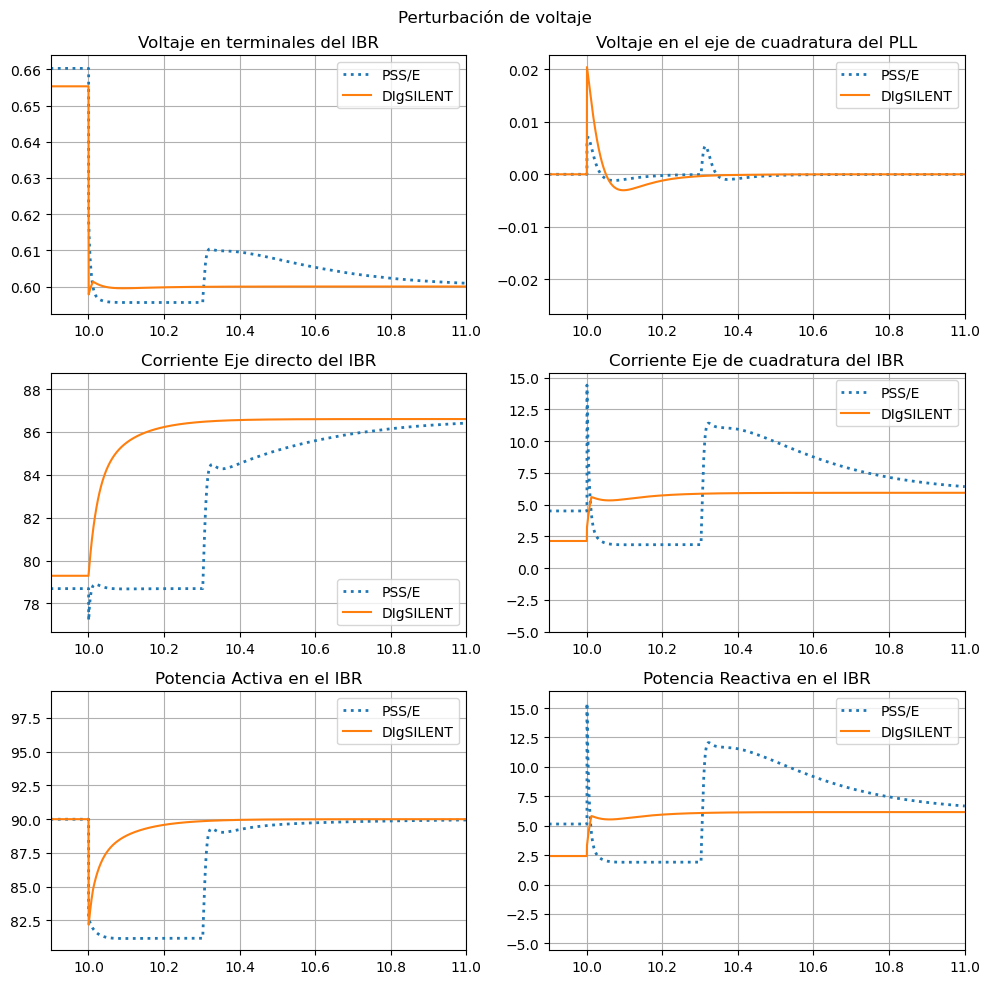

In [71]:
pss_data = pss_vol
dsl_data = dsl_vol
minx = 9.9
maxx = 11

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de voltaje')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 6 - Escalon Paux

### POI

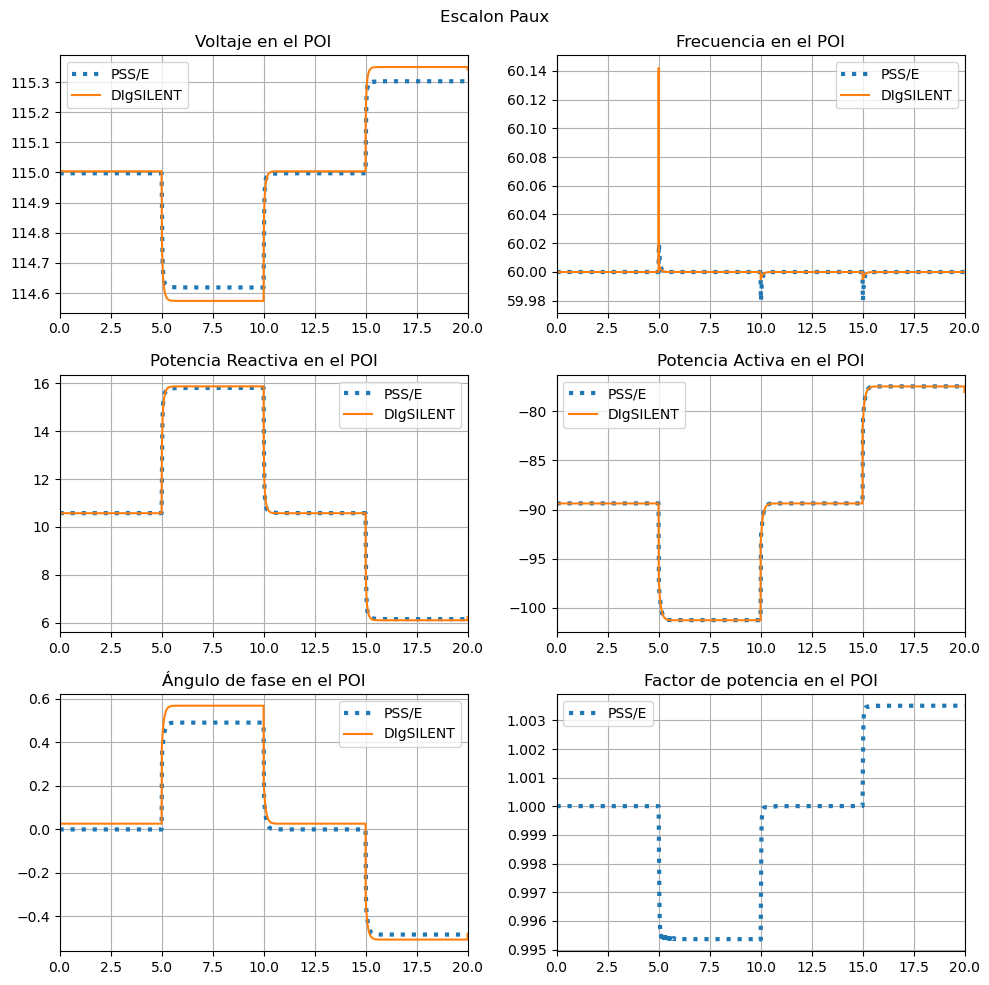

In [72]:
pss_data = pss_pax
dsl_data = dsl_pax
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Paux')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()


    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

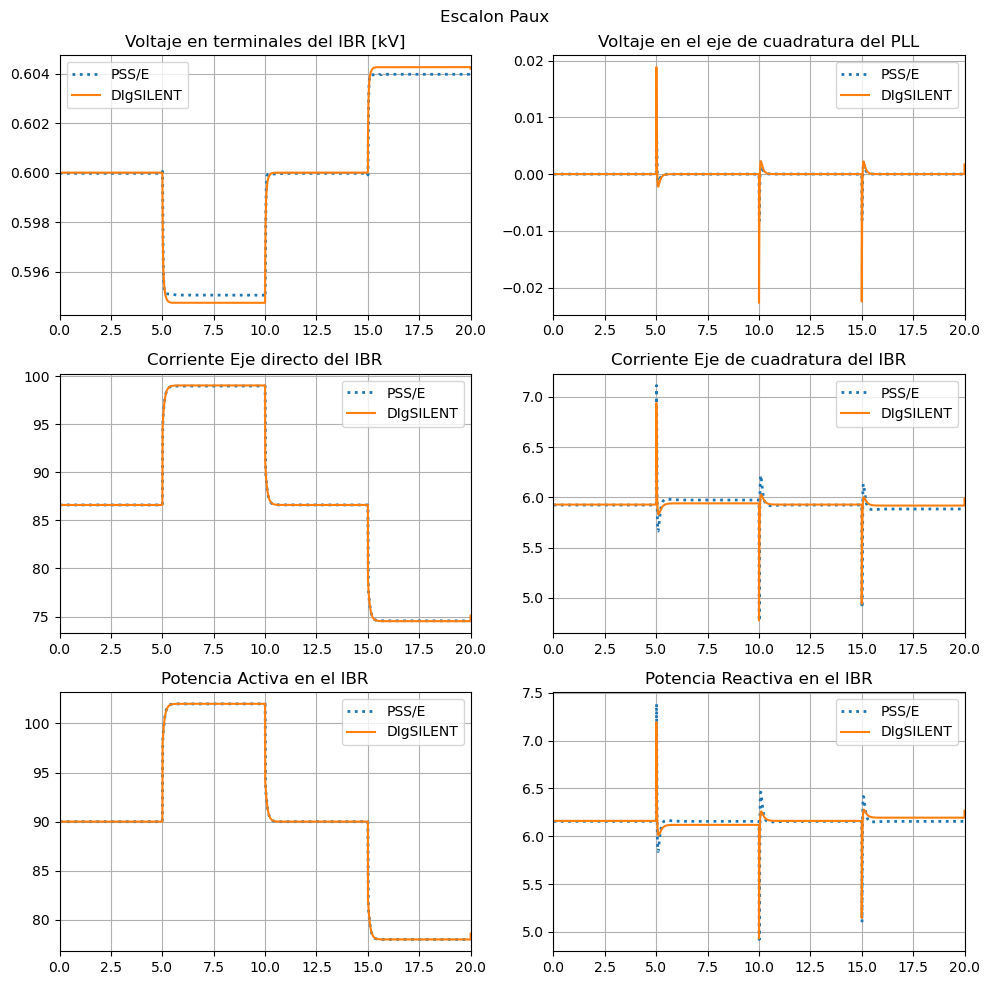

In [73]:
pss_data = pss_pax
dsl_data = dsl_pax
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Paux')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR [kV]')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 7 - Escalon Pref

### POI

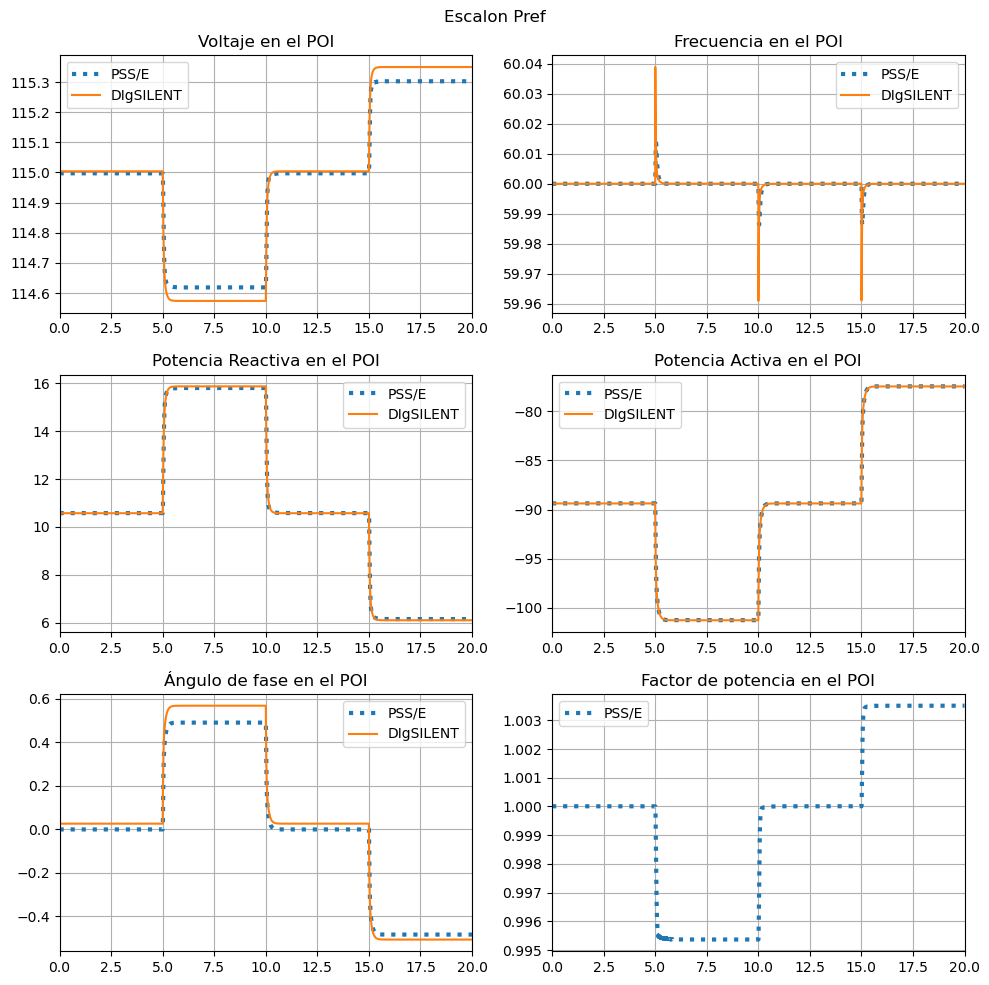

In [74]:
pss_data = pss_prf
dsl_data = dsl_prf
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Pref')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

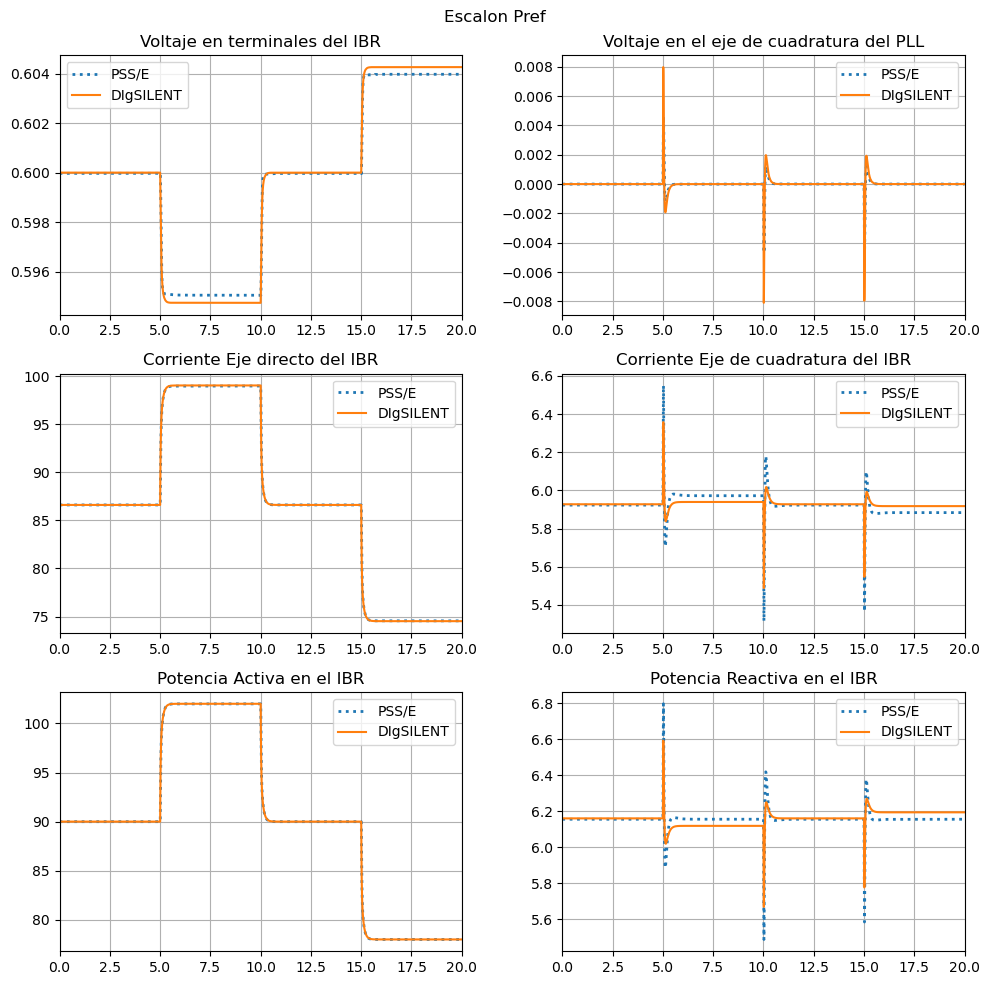

In [75]:
pss_data = pss_prf
dsl_data = dsl_prf
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Pref')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 8 - Escalon Qref

### POI

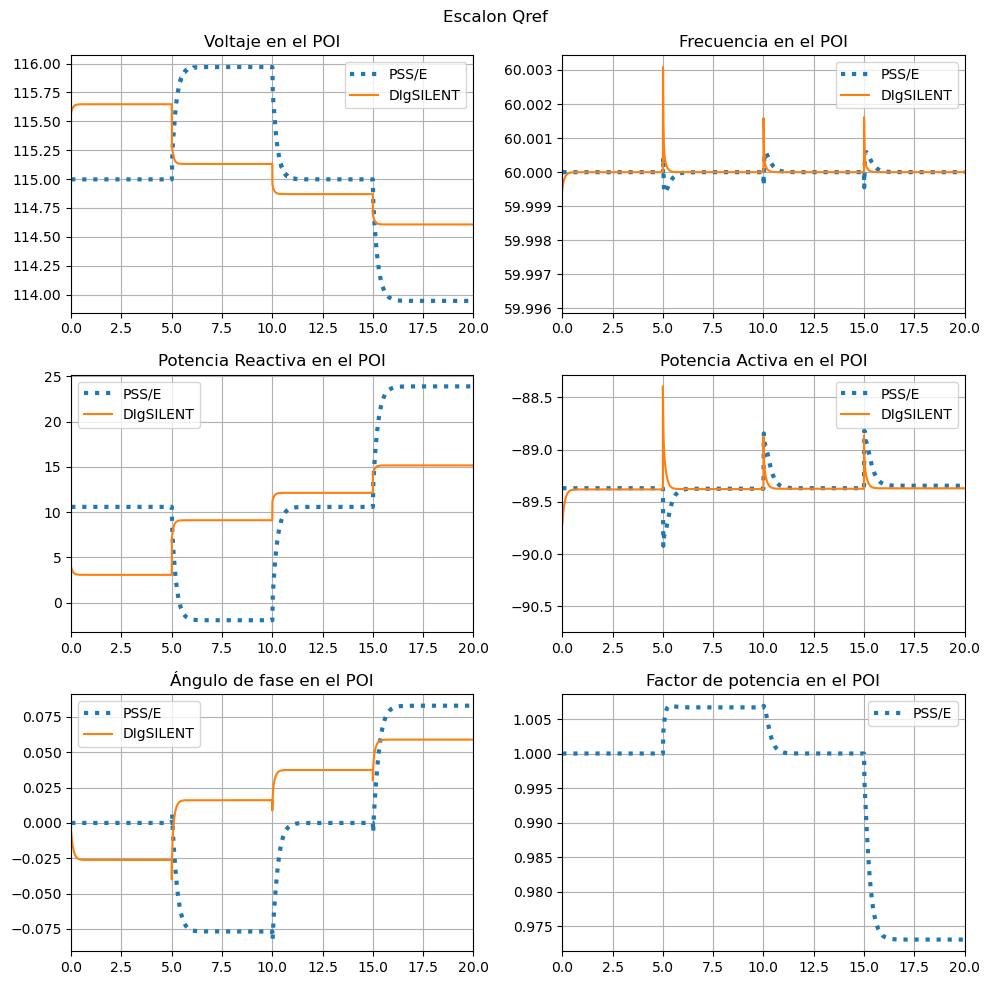

In [84]:
pss_data = pss_qrf
dsl_data = dsl_qrf
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Qref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

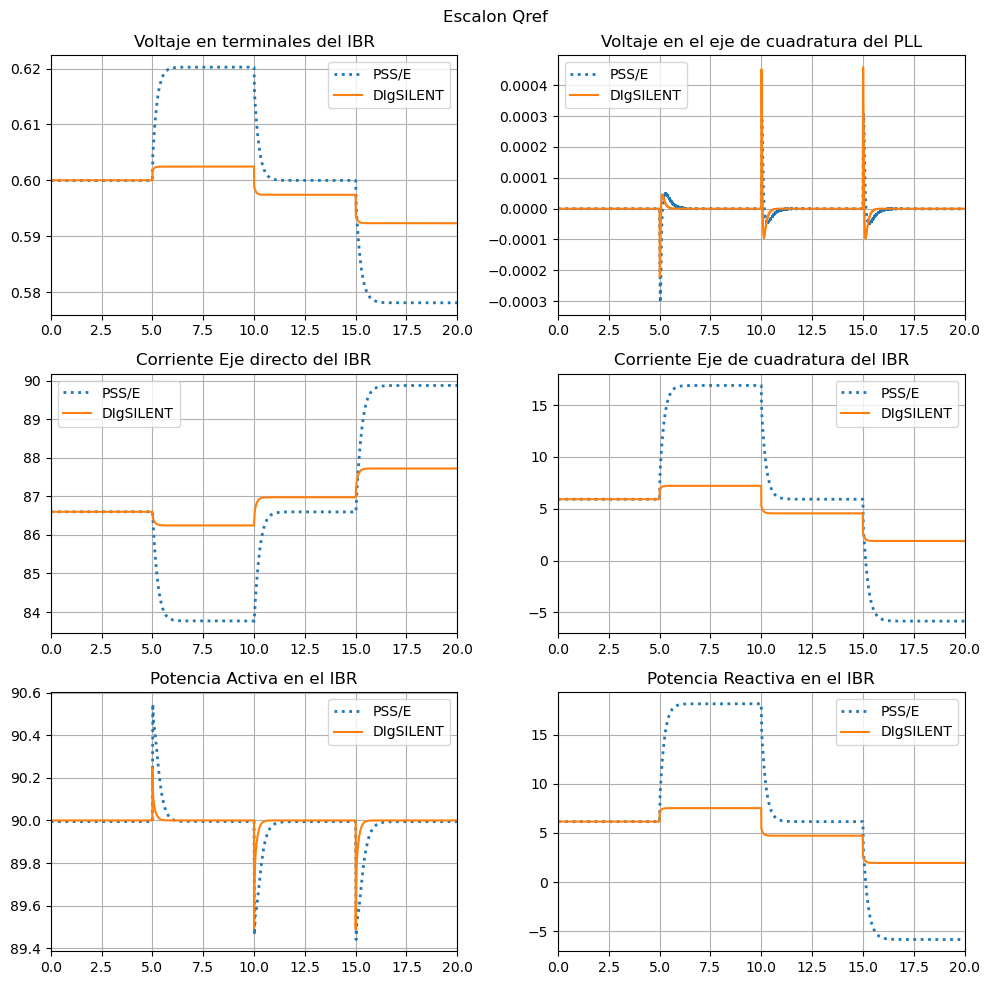

In [77]:
pss_data = pss_qrf
dsl_data = dsl_qrf
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Qref')
    
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 9 - Escalon PFref

### POI

In [78]:
pss_data = pss_PFr
dsl_data = dsl_PFr
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon PFref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    #axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI Bus m:pf in pu'], label='DIgSILENT')
    #axs[2,1].set_ylim(0.9,1.0)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


### IBR

In [79]:
pss_data = pss_PFr
dsl_data = dsl_PFr
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('Escalon PFref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


In [80]:
#### Código para asignar las mismas variables a tooodos los casos de estudio. Se encuentra sin completar ##################
# oFoldStudy = app.GetProjectFolder('study')  # Obtenemos la carpeta de estudio del proyecto
# sStudyCase = oFoldStudy.GetContents('*.IntCase', 1)  # Obtenemos todos los casos de estudio del proyecto
# sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

# oFoldLib = app.GetProjectFolder('lib')
# oGenResults = oFoldLib.GetContents('General calculations.ElmRes')[0]  # Obtenemos el elemento de resultados genéricos
# sVarResults = oGenResults.GetContents('*.IntMon')

# app.PrintPlain(oGenResults)

# for oStudyCase in sStudyCase:
#     oLocResults = oStudyCase.GetContents('*.ElmRes')[0]  # Obtenemos los resultados específicos del caso de estudio
#     oComInc = oStudyCase.GetContents('*.ComInc')[0]  # Obtenemos los incrementos de carga específicos del caso de estudio
#     oComInc.p_resvar = oGenResults # Asignamos el archivo de resultados general a cada caso de estudios
#     app.PrintPlain(f"   Resultados locales de {oStudyCase}: {oComInc.p_resvar}...")
#     oLocResults.D